# Multi-Compartment Hodgkin-Huxley Network

This notebook demonstrates the multi-compartment HH neuron model and network
capabilities added to `neuro_framework`. It covers:

1. Loading SWC morphologies and building single-neuron models
2. Simulating action potentials in a multi-compartment neuron
3. Building networks with different synapse models
4. Training the network with gradient descent
5. Loading real SWC morphologies (12k+ compartments, sparse solver)

In [1]:
import sys, os, tempfile, time
sys.path.insert(0, os.path.abspath('../..'))

import torch
import numpy as np
import matplotlib.pyplot as plt

from neuro_framework.models import (
    MultiCompartmentHH, MCNetwork, MorphologyGraph,
    IonotropicSynapse, NMDASynapse, GABAaSynapse,
)
from neuro_framework.training.trainer import TorchTrainer

print(f'PyTorch {torch.__version__}')

PyTorch 2.2.0


## 1. Create Test Morphology

In [2]:
swc_content = (
    '# Branching test neuron\n'
    '1 1 0.0 0.0 0.0 5.0 -1\n'
    '2 3 25.0 0.0 0.0 3.0 1\n'
    '3 3 50.0 0.0 0.0 2.5 2\n'
    '4 3 80.0 0.0 0.0 2.0 3\n'
    '5 3 110.0 0.0 0.0 1.5 4\n'
    '6 3 140.0 0.0 0.0 1.0 5\n'
    '7 3 25.0 20.0 0.0 3.0 1\n'
    '8 3 50.0 40.0 0.0 2.5 7\n'
    '9 3 80.0 60.0 0.0 2.0 8\n'
    '10 3 110.0 80.0 0.0 1.5 9\n'
)

swc_file = tempfile.NamedTemporaryFile(mode='w', suffix='.swc', delete=False)
swc_file.write(swc_content)
swc_file.close()
swc_path = swc_file.name

morph = MorphologyGraph.from_swc(swc_path, ncomp=1)
print(f'Branches: {morph.n_branches}, Compartments: {morph.n_comp}')
print(f'Total surface area: {morph.areas.sum():.1f} um^2')

Branches: 3, Compartments: 3
Total surface area: 4632.0 um^2


## 2. Single Neuron Simulation

MultiCompartmentHH(n_comp=3, n_branches=3)


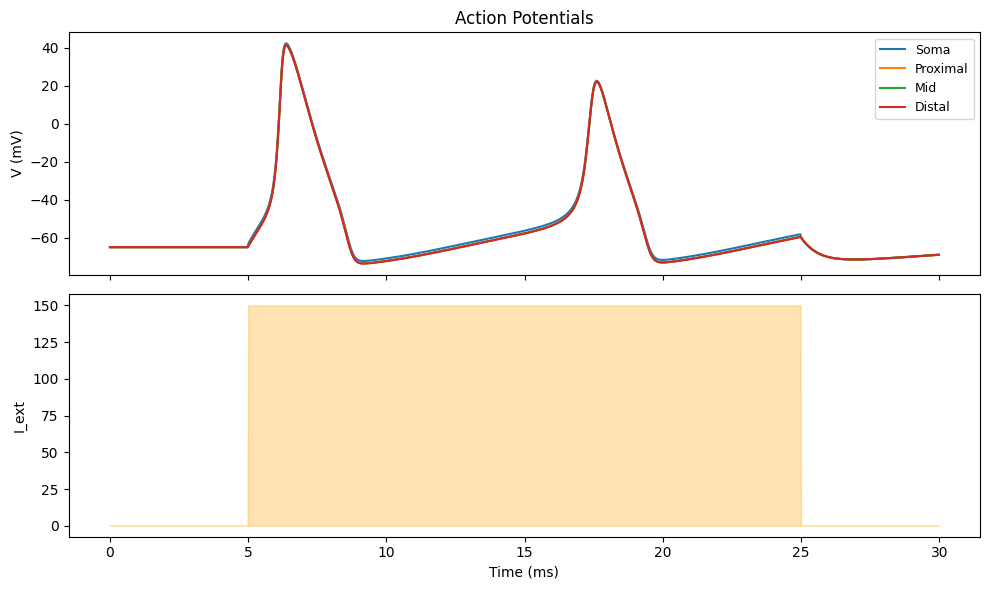

Soma V range: [-72.3, 42.4] mV


In [3]:
neuron = MultiCompartmentHH.from_swc(swc_path, ncomp=1)
print(neuron)

dt = 0.025
T_ms = 30.0
T_steps = int(T_ms / dt)
t = np.arange(T_steps) * dt

I_ext = torch.zeros(1, T_steps, neuron.n_comp, dtype=torch.float64)
I_ext[0, int(5/dt):int(25/dt), 0] = 150.0

with torch.no_grad():
    V_trace = neuron.simulate(I_ext, dt=dt)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
comp_ids = [0, 1, neuron.n_comp//2, neuron.n_comp-1]
labels = ['Soma', 'Proximal', 'Mid', 'Distal']
for ci, lab in zip(comp_ids, labels):
    axes[0].plot(t, V_trace[0, :, ci].numpy(), label=lab, linewidth=1.5)
axes[0].set_ylabel('V (mV)'); axes[0].set_title('Action Potentials')
axes[0].legend(fontsize=9)
axes[1].fill_between(t, 0, I_ext[0, :, 0].numpy(), alpha=0.3, color='orange')
axes[1].set_ylabel('I_ext'); axes[1].set_xlabel('Time (ms)')
plt.tight_layout()
os.makedirs('../logs', exist_ok=True)
plt.savefig('../logs/mc_hh_single_neuron.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Soma V range: [{V_trace[0,:,0].min():.1f}, {V_trace[0,:,0].max():.1f}] mV')

## 3. MC Network with Different Synapse Models

In [4]:
n_neurons = 5
pre_idx = torch.tensor([0, 1, 2, 3])
post_idx = torch.tensor([1, 2, 3, 4])
n_edges = len(pre_idx)

synapse_configs = {
    'Ionotropic (E=0)': IonotropicSynapse(n_edges, gS=0.5, e_syn=0.0),
    'NMDA (E=0)': NMDASynapse(n_edges, gS=0.5, e_syn=0.0),
    'GABA_A (E=-80)': GABAaSynapse(n_edges, gS=0.5, e_syn=-80.0),
}

T_steps = int(40.0 / 0.025)
t = np.arange(T_steps) * 0.025
x = torch.zeros(1, T_steps, n_neurons, dtype=torch.float32)
x[0, int(5/0.025):int(30/0.025), 0] = 150.0

results = {}
for name, syn_model in synapse_configs.items():
    net = MCNetwork(morph=morph, n_neurons=n_neurons,
                    pre_neuron_idx=pre_idx, post_neuron_idx=post_idx,
                    synapse_model=syn_model, init_weight_scale=1.0, dt=0.025)
    with torch.no_grad():
        out = net(x)
    results[name] = out[0].numpy()
    print(f'{name:25s}: N0=[{out[0,:,0].min():.1f},{out[0,:,0].max():.1f}]  '
          f'N1=[{out[0,:,1].min():.1f},{out[0,:,1].max():.1f}]')

Ionotropic (E=0)         : N0=[-76.0,42.4]  N1=[-75.2,36.3]
NMDA (E=0)               : N0=[-76.0,42.4]  N1=[-65.0,-64.4]
GABA_A (E=-80)           : N0=[-76.0,42.4]  N1=[-66.8,-65.0]


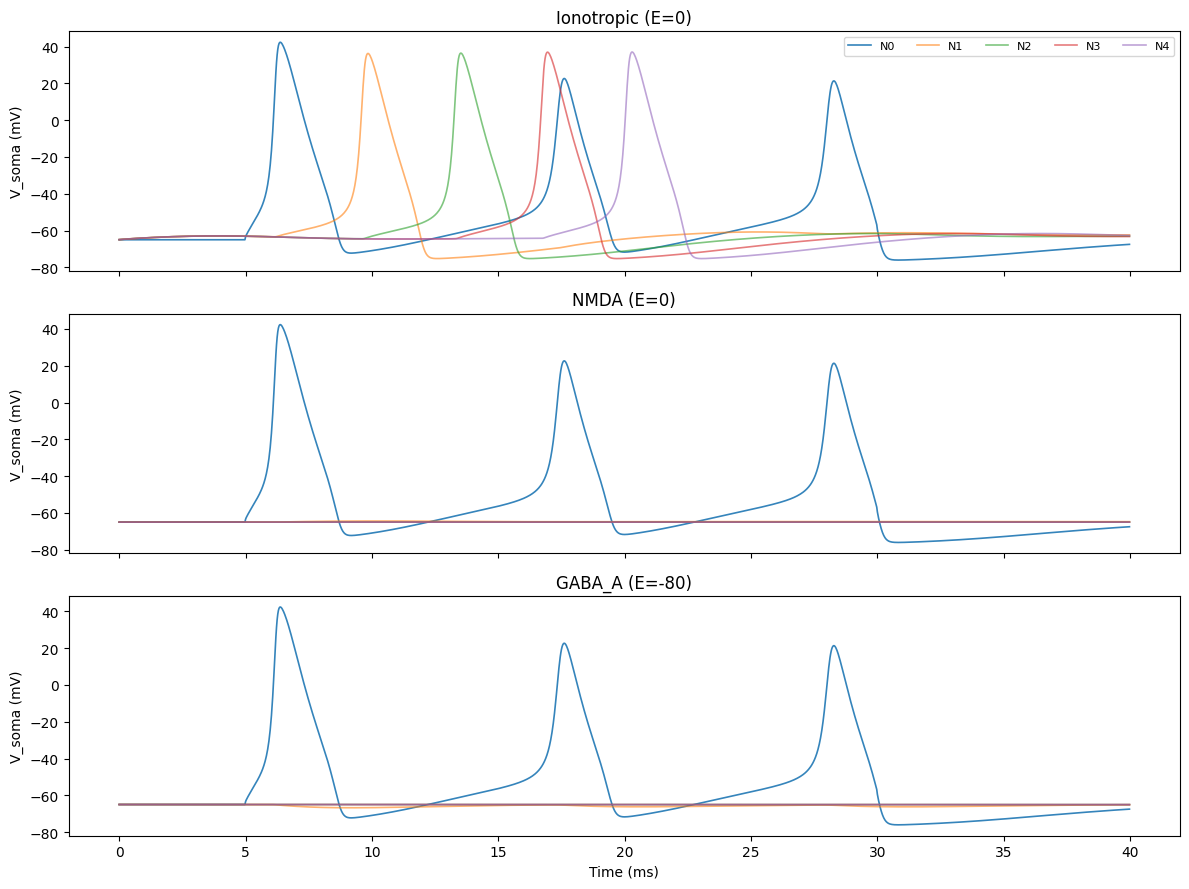

In [5]:
fig, axes = plt.subplots(len(results), 1, figsize=(12, 3 * len(results)),
                         sharex=True, sharey=True)
for ax, (name, traces) in zip(axes, results.items()):
    for ni in range(n_neurons):
        ax.plot(t, traces[:, ni], label=f'N{ni}', linewidth=1.2,
                alpha=0.9 if ni == 0 else 0.6)
    ax.set_ylabel('V_soma (mV)'); ax.set_title(name)
    if ax is axes[0]: ax.legend(ncol=n_neurons, fontsize=8)
axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.savefig('../logs/mc_hh_synapse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Training with TorchTrainer

In [6]:
torch.manual_seed(42)
net_train = MCNetwork(morph=morph, n_neurons=n_neurons,
                      pre_neuron_idx=pre_idx, post_neuron_idx=post_idx,
                      synapse_model='ionotropic', init_weight_scale=0.1,
                      dt=0.025, learn_hh_params=True)
print(f'Trainable params: {net_train.n_parameters()}')

n_samples, T_train = 4, 100
x_train = torch.zeros(n_samples, T_train, n_neurons, dtype=torch.float32)
for s in range(n_samples):
    x_train[s, 10:80, 0] = 100.0 + 50.0 * s

with torch.no_grad():
    y_target = net_train(x_train) + 2.0 * torch.randn(n_samples, T_train, n_neurons)

import logging; logging.basicConfig(level=logging.INFO, format='%(message)s')
trainer = TorchTrainer(net_train, optimizer_cfg={'lr': 5e-4}, clip_grad=1.0)
history = trainer.train(x_train, y_target, n_epochs=30, batch_size=2, log_every=5)
print(f'Final loss: {history.train_loss[-1]:.4f}')

Trainable params: 32


Epoch    5/30  train=3.9267  [1.2s]
Epoch   10/30  train=3.9240  [2.5s]
Epoch   15/30  train=3.9230  [3.6s]
Epoch   20/30  train=3.9224  [4.9s]
Epoch   25/30  train=3.9222  [6.2s]
Epoch   30/30  train=3.9221  [7.4s]


Final loss: 3.9221


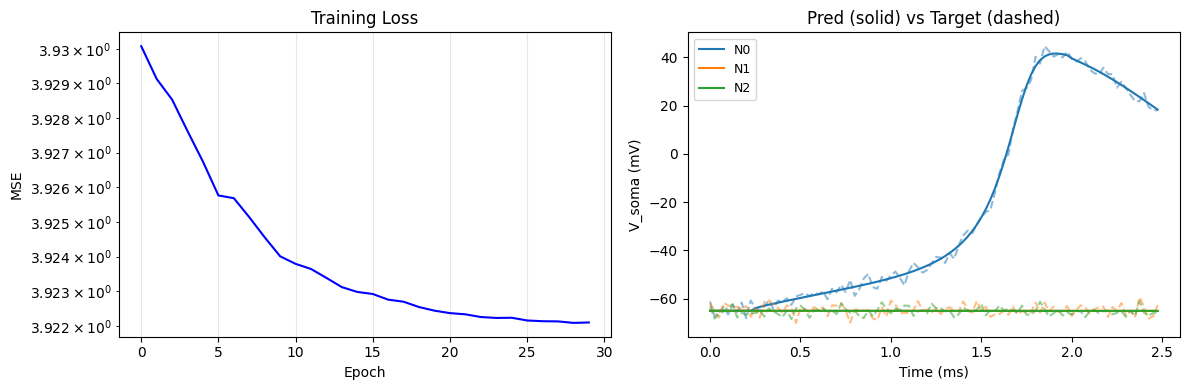

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.train_loss, 'b-'); axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE'); axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

net_train.eval()
with torch.no_grad():
    y_pred = net_train(x_train[:1])
t_plot = np.arange(T_train) * 0.025
for ni in range(min(3, n_neurons)):
    axes[1].plot(t_plot, y_target[0, :, ni].numpy(), '--', color=f'C{ni}', alpha=0.5)
    axes[1].plot(t_plot, y_pred[0, :, ni].numpy(), '-', color=f'C{ni}', linewidth=1.5,
                 label=f'N{ni}')
axes[1].set_xlabel('Time (ms)'); axes[1].set_ylabel('V_soma (mV)')
axes[1].set_title('Pred (solid) vs Target (dashed)'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('../logs/mc_hh_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Real SWC Morphology (Sparse Solver)

For large morphologies (>500 compartments), the solver automatically switches
from dense `torch.linalg.solve` to a memory-efficient sparse Jacobi iteration.

Branches: 12563, Compartments: 12563
Solver: sparse-jacobi  |  Load time: 1.95s
Simulation (800 steps): 5.80s


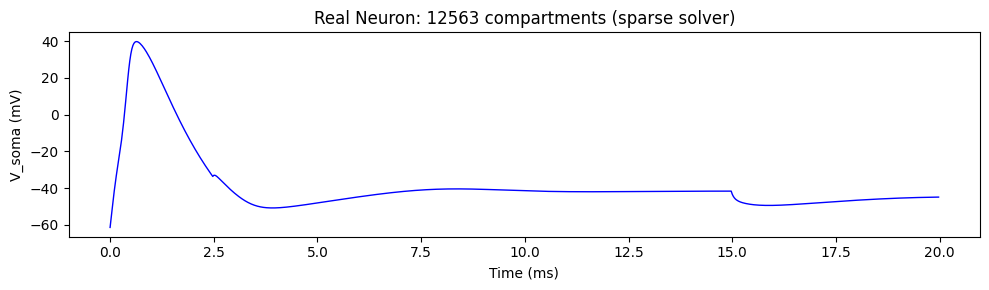

V[soma]: [-61.4, 39.8] mV


In [8]:
real_swc = '../../Jaxley_notebook/jaxley_tutorial-sjcabs/tutorial/ct1_10009.swc'

if os.path.exists(real_swc):
    t0 = time.time()
    real_morph = MorphologyGraph.from_swc(real_swc, ncomp=1)
    print(f'Branches: {real_morph.n_branches}, Compartments: {real_morph.n_comp}')
    print(f'Solver: sparse-jacobi  |  Load time: {time.time()-t0:.2f}s')

    real_neuron = MultiCompartmentHH(real_morph)

    T_steps = 800
    I_real = torch.zeros(1, T_steps, real_morph.n_comp, dtype=torch.float64)
    I_real[0, 100:600, 0] = 100.0

    t0 = time.time()
    with torch.no_grad():
        V_real = real_neuron.simulate(I_real, dt=0.025)
    print(f'Simulation ({T_steps} steps): {time.time()-t0:.2f}s')

    t_real = np.arange(T_steps) * 0.025
    plt.figure(figsize=(10, 3))
    plt.plot(t_real, V_real[0, :, 0].numpy(), 'b-', linewidth=1)
    plt.xlabel('Time (ms)'); plt.ylabel('V_soma (mV)')
    plt.title(f'Real Neuron: {real_morph.n_comp} compartments (sparse solver)')
    plt.tight_layout()
    plt.savefig('../logs/mc_hh_real_neuron.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'V[soma]: [{V_real[0,:,0].min():.1f}, {V_real[0,:,0].max():.1f}] mV')
else:
    print('SWC file not found, skipping.')

In [9]:
os.unlink(swc_path)
print('Done.')

Done.
